# Introducción a MLOps (Notebook 01)

En este notebook vas a recorrer un flujo completo (y reproducible) de *machine learning* para **clasificación binaria** usando *scikit-learn*:

- Generación de datos sintéticos (con valores faltantes para simular “datos reales”).
- EDA mínimo para entender tipos de variables y calidad del dataset.
- Feature engineering sencillo.
- Split de train/test.
- **Pipeline** de preprocesamiento + modelo (evita *data leakage*).
- Evaluación con métricas: *accuracy*, *precision*, *recall*, *F1*, ROC-AUC, matriz de confusión y efectos del **umbral** (*threshold*).

Objetivo: no “ganar” el mejor score (los datos son sintéticos), sino practicar buenas prácticas y entender qué significa la salida del modelo.
__________________________________

## ¿Qué es *data leakage*? (explicación fácil)

**Data leakage** (fuga de información) pasa cuando el modelo “hace trampa” sin querer, porque en entrenamiento ve información que **no debería ver**.

Piensa en esto:

- En `train` el modelo *aprende*.
- En `test` el modelo debe comportarse como si fueran **datos nuevos**.

Hay *leakage* si (por accidente) usas datos del `test` para preparar el `train`.

### Ejemplo muy común
Si calculas la **mediana** para imputar valores faltantes usando *todo el dataset* (train + test), entonces el modelo está usando información del test.

### ¿Por qué el `Pipeline` ayuda?
Porque el flujo correcto es:

1. Separar `train/test`
2. Hacer `pipeline.fit(X_train, y_train)` → aquí el pipeline aprende (medianas, escalado, one-hot) **solo con train**
3. Hacer `pipeline.predict(X_test)` → aquí solo aplica las mismas reglas al test

Resultado: la evaluación es más realista (más parecida a producción).

Ejemplo:
Supongamos un dataset con una feature a la cual le hacen falta valores en algunos registros.

- Calculas la mediana solo con X_train.
- Rellenas X_train con esa mediana.
- Rellenas X_test con esa misma mediana (la del train).

In [2]:
%load_ext autoreload
%reload_ext autoreload

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from generate_data import UserGenerator

In [4]:
generator_data = UserGenerator(seed=42, n_samples=10000)
df = generator_data.create_dataset()

df.head()

Generando datos sintéticos de usuarios para targeting de promociones...
✅ Agregados 493 valores nulos en 'age_group' (5.0%)
✅ Agregados 298 valores nulos en 'location' (3.0%)
✅ Agregados 181 valores nulos en 'device_type' (2.0%)
✅ Agregados 106 valores nulos en 'subscription_type' (1.0%)
✅ Agregados 777 valores nulos en 'avg_order_value' (8.0%)
✅ Agregados 1474 valores nulos en 'last_purchase_days' (15.0%)
✅ Agregados 999 valores nulos en 'time_on_site_minutes' (10.0%)
✅ Agregados 954 valores nulos en 'pages_per_session' (10.0%)
✅ Agregados 1221 valores nulos en 'cart_abandonment_rate' (12.0%)
✅ Agregados 800 valores nulos en 'purchase_frequency' (8.0%)


,user_id,age_group,location,device_type,subscription_type,days_since_registration,total_purchases,avg_order_value,last_purchase_days,sessions_last_30_days,time_on_site_minutes,pages_per_session,cart_abandonment_rate,purchase_frequency,dar_promocion
0,USER-000001,18-25,Mendoza,Mobile,Free,38,6,341.58,139.0,2,71.3,NaN,0.075,4.74,1
1,USER-000002,26-35,Buenos Aires,Mobile,Basic,246,34,215.56,114.0,18,34.1,17.5,0.607,4.15,0
2,USER-000003,36-45,Buenos Aires,Mobile,Enterprise,284,21,60.08,97.0,3,43.7,7.5,0.212,2.22,1
3,USER-000004,36-45,Cordoba,Tablet,Free,343,35,153.66,160.0,19,106.4,7.9,0.154,3.06,0
4,USER-000005,18-25,Buenos Aires,Mobile,Free,330,14,434.58,97.0,8,55.0,16.8,0.130,1.27,1


## 1) EDA rápido: entender los datos

En esta sección buscamos:

- Tipos de variables:
  - **Categóricas** (texto / `object`): requieren codificación (por ejemplo One-Hot).
  - **Numéricas** (`int`, `float`): suelen requerir imputación y, para algunos modelos, escalado.
- Calidad del dataset:
  - Porcentaje de valores faltantes (`NaN`).
  - Rangos de valores y posibles outliers.

Nota MLOps: la imputación/transformaciones se deben hacer **dentro del pipeline** para evitar *data leakage* (contaminar el entrenamiento con información del test).

<Axes: >

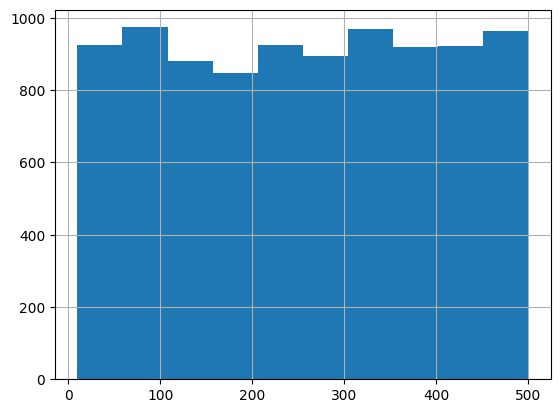

In [5]:
df.avg_order_value.hist()

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_id                  10000 non-null  object 
 1   age_group                9507 non-null   object 
 2   location                 9702 non-null   object 
 3   device_type              9819 non-null   object 
 4   subscription_type        9894 non-null   object 
 5   days_since_registration  10000 non-null  int64  
 6   total_purchases          10000 non-null  int64  
 7   avg_order_value          9223 non-null   float64
 8   last_purchase_days       8526 non-null   float64
 9   sessions_last_30_days    10000 non-null  int64  
 10  time_on_site_minutes     9001 non-null   float64
 11  pages_per_session        9046 non-null   float64
 12  cart_abandonment_rate    8779 non-null   float64
 13  purchase_frequency       9200 non-null   float64
 14  dar_promocion          

In [7]:
df.isnull().sum()

user_id                       0
age_group                   493
location                    298
device_type                 181
subscription_type           106
days_since_registration       0
total_purchases               0
avg_order_value             777
last_purchase_days         1474
sessions_last_30_days         0
time_on_site_minutes        999
pages_per_session           954
cart_abandonment_rate      1221
purchase_frequency          800
dar_promocion                 0
dtype: int64

## 2) Feature engineering (crear más features)

Feature engineering = crear variables nuevas a partir de variables existentes.

- Puede mejorar la señal del modelo (resumir patrones útiles).
- Riesgo: **data leakage** si una feature usa información que no estaría disponible al momento de predecir en producción.

En este caso creamos features derivadas simples (tasas / diferencias) para practicar el flujo.

In [8]:
days = df['days_since_registration'].clip(lower=1)  # Evitar división por cero, dejar 1 si el valor es menor a 0

df['total_purchases_per_day'] = df['total_purchases'] / days

df["days_between_first_and_last_purchase"] = df["days_since_registration"] - df["last_purchase_days"]

df["bucket_avg_order_value"] = pd.cut(df["avg_order_value"], bins=3, labels=["low", "medium", "high"])

df['estimated_lifetime_value'] = df['avg_order_value'] * df['total_purchases'] # para estimar el beneficio neto total de un cliente o su lifetime value (LTV).

df['engagement_per_session'] = df['pages_per_session'] / (df['time_on_site_minutes'] + 1) # indica qué tan "activo" es el usuario por minuto en el sitio. Valores altos sugieren usuarios más interesados.


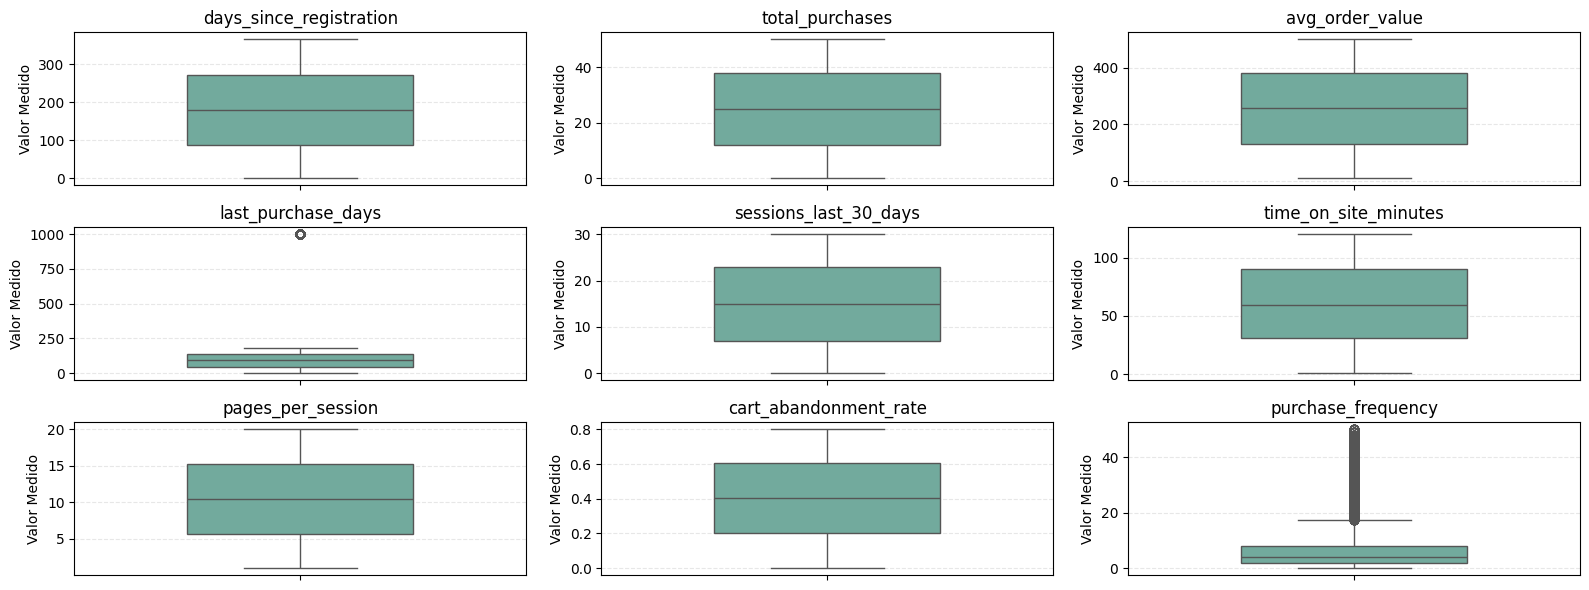

In [9]:
import matplotlib.pyplot as plt

variables = [
    "days_since_registration",
    "total_purchases",
    "avg_order_value",
    "last_purchase_days",
    "sessions_last_30_days",
    "time_on_site_minutes",
    "pages_per_session",
    "cart_abandonment_rate",
    "purchase_frequency",
]

plt.figure(figsize=(16, 6))

for i, var in enumerate(variables, 1):

    plt.subplot(3, 3, i)

    sns.boxplot(y=df[var], color='#69b3a2', width=0.5)

    plt.title(f'{var}', fontsize=12)
    plt.ylabel('Valor Medido')
    plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## 3) Split de datos (train/test)

Separaremos los datos para simular el escenario real:

- Entrenas con `train`.
- Evalúas con `test` (datos “nuevos” para el modelo).

`random_state` asegura reproducibilidad.

`X` = features (entradas) y `y` = target (lo que quieres predecir).

In [10]:
# train test split
from sklearn.model_selection import train_test_split

X = df.drop(columns=["dar_promocion"])
y = df["dar_promocion"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,
    random_state=42,
)

## 4) Preprocesamiento: numéricas vs categóricas (y por qué)

En este dataset tienes dos familias de features:

### Variables numéricas
Ejemplos: `avg_order_value`, `time_on_site_minutes`, `purchase_frequency`.

- **Imputación**: muchos modelos no aceptan `NaN`.
- **Escalado** (por ejemplo `StandardScaler`): en modelos lineales (Logistic Regression) ayuda porque hace comparables las magnitudes.

### Variables categóricas
Ejemplos: `age_group`, `location`, `device_type`, `subscription_type`.

- Deben convertirse a números. La opción clásica es **One-Hot Encoding**.
- `handle_unknown='ignore'`: si aparece una categoría nueva en producción, el pipeline no falla.

### Por qué `ColumnTransformer`
Permite aplicar transformaciones diferentes a subconjuntos de columnas (numéricas vs categóricas) en un solo objeto reproducible.

## 5) Pipeline: preprocesamiento + modelo (evitar data leakage)

Usaremos:

- `Pipeline`: encapsula todos los pasos (imputación, escalado, one-hot, modelo).
- `ColumnTransformer`: separa numéricas/categóricas.

Punto clave: si haces imputación/one-hot *antes* del split o fuera del pipeline, podrías mezclar información del test en el entrenamiento (data leakage).

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer, KNNImputer
from category_encoders import BinaryEncoder


# Define numeric and categorical columns
numeric_features = [
    "days_since_registration",
    "total_purchases",
    "avg_order_value",
    "last_purchase_days",
    "sessions_last_30_days",
    "time_on_site_minutes",
    "pages_per_session",
    "cart_abandonment_rate",
    "purchase_frequency",
]

categorical_features = ["age_group", "location", "device_type", "subscription_type"]

# Create preprocessing pipelines for each data type
numeric_transformer = Pipeline(
    steps=[
        ("imputer", KNNImputer(n_neighbors=3)), # imputar para reemplazar valores faltantes usando KNNImputer, que utiliza los valores de los vecinos más cercanos para imputar los valores faltantes
       #("imputer", SimpleImputer(strategy="median")), # imputar para reemplazar valores faltantes
        ("scaler", MinMaxScaler())
       #("scaler", StandardScaler()), # escalar para tener las variables en la misma escala, lo que hace es cambiar la magnitud de las variables para que puedan ser comparables
        # el modelo de regresión logística es sensible a la escala de las variables, no queremos que el modelo le de más peso a cierta variable solo porque tiene valores más grandes
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")), # si hay un valor en tests que no estaba en train, lo reemplaza por Unknown
        (
            ("binary", BinaryEncoder())
            #"onehot",
            #OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"), # drop="first" para evitar la multicolinealidad, handle_unknown="ignore" para ignorar valores desconocidos
        ),
    ]
)

# Combine transformers using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

# Create the full pipeline
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(random_state=42, n_estimators=100,  max_depth=5, min_samples_split=2, min_samples_leaf=1)),
        #("classifier", LogisticRegression(random_state=42, max_iter=1000)),
    ]
)



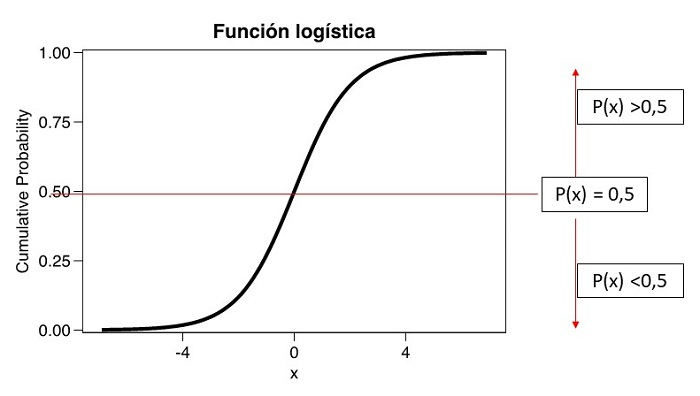

### Gridsearch

In [228]:
from sklearn.model_selection import GridSearchCV
# definir los hiperparametros a buscar
param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 5, 10, 20],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__max_features": ["sqrt", "log2"],
    "preprocessor__num__imputer__n_neighbors": [3, 5, 7, 10],
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,                   # validación cruzada de 5 folds
    scoring="accuracy",     # métrica de evaluación
    n_jobs=-1,              # usar todos los núcleos
    verbose=2               # mostrar progreso
)

# entrenar
grid_search.fit(X_train, y_train)

# mejor combinacion de hiperparametros
print(grid_search.best_params_)

# mejor score obtenido
print(grid_search.best_score_)

# mejor modelo completo listo para usar
best_model = grid_search.best_estimator_

Fitting 5 folds for each of 864 candidates, totalling 4320 fits
{'classifier__max_depth': 10, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 100, 'preprocessor__num__imputer__n_neighbors': 7}
0.5054444444444445


In [12]:
# Fit the pipeline
pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer(n_neighbors=3)),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['days_since_registration',
                                                   'total_purchases',
                                                   'avg_order_value',
                                                   'last_purchase_days',
                                                   'sessions_last_30_days',
                                                   'time_on_site_minutes',
                                                   'pages_per_session',
                                                   'cart_abandonment_rate',
                                                   'purchase_frequency']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Unknown',
                                                                                 strategy='constant')),
                                                                  ('binary',
                                                                   BinaryEncoder())]),
                                                  ['age_group', 'location',
                                                   'device_type',
                                                   'subscription_type'])])),
                ('classifier',
                 RandomForestClassifier(max_depth=5, random_state=42))])

### (Opcional) Ver cuántas features quedan después del preprocesamiento

`OneHotEncoder` puede expandir bastante el número de columnas. Esto es normal. Aquí solo inspeccionamos:

- cuántas columnas finales existen
- algunos nombres generados

Esto es útil para debugging e interpretabilidad (aun si luego no interpretas coeficientes).

In [13]:
try:
    feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()
    print("Nº de features después del preprocesamiento:", len(feature_names))
    pd.Series(feature_names).head(20)
except Exception as e:
    print("No se pudieron obtener los nombres de features:", e)

Nº de features después del preprocesamiento: 21


In [14]:
feature_names

array(['num__days_since_registration', 'num__total_purchases',
       'num__avg_order_value', 'num__last_purchase_days',
       'num__sessions_last_30_days', 'num__time_on_site_minutes',
       'num__pages_per_session', 'num__cart_abandonment_rate',
       'num__purchase_frequency', 'cat__0_0', 'cat__0_1', 'cat__0_2',
       'cat__1_0', 'cat__1_1', 'cat__1_2', 'cat__2_0', 'cat__2_1',
       'cat__2_2', 'cat__3_0', 'cat__3_1', 'cat__3_2'], dtype=object)

In [15]:
# Predicciones
# - y_pred: clase predicha usando el umbral por defecto (0.5)
# - y_pred_proba: probabilidad estimada de la clase positiva (y=1)

y_pred = pipeline.predict(X_test)
y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

In [16]:
y_pred_proba

array([0.50652853, 0.50418808, 0.51492397, 0.49738592, 0.52303457,
       0.50217191, 0.49592191, 0.50599857, 0.50156844, 0.50019658,
       0.49606818, 0.48015566, 0.53045835, 0.50023732, 0.46763749,
       0.4520964 , 0.49381901, 0.51704034, 0.52038846, 0.49040874,
       0.50724624, 0.49865519, 0.50752638, 0.4944153 , 0.51598063,
       0.51074864, 0.50505835, 0.50150921, 0.50397681, 0.49820818,
       0.50713355, 0.51753237, 0.51923589, 0.49902595, 0.49476555,
       0.52946081, 0.49726262, 0.50297657, 0.53187771, 0.51522934,
       0.49308125, 0.49944309, 0.49898806, 0.50260886, 0.50550379,
       0.50789471, 0.49912735, 0.50588016, 0.41502582, 0.54122784,
       0.49946952, 0.49025952, 0.51304075, 0.49955001, 0.50958234,
       0.50669586, 0.49088561, 0.49963143, 0.50034515, 0.51018213,
       0.49623008, 0.51338541, 0.48977587, 0.49532986, 0.49088129,
       0.50368728, 0.50908619, 0.46986806, 0.49174677, 0.49746296,
       0.48964895, 0.4922282 , 0.527702  , 0.47857223, 0.49193

## 6) Métricas de clasificación: cómo leer el reporte

`classification_report` muestra, por clase:

- **precision**: de lo que el modelo predijo como positivo, ¿cuánto fue correcto?
- **recall**: de los positivos reales, ¿cuántos detectó?
- **f1-score**: balance entre precision y recall (útil cuando quieres un trade-off).
- **support**: cuántos ejemplos hay de cada clase.

Promedios:

- **macro avg**: promedio simple entre clases (cada clase pesa igual). Útil si quieres tratar todas las clases con la misma importancia.
- **weighted avg**: promedio ponderado por `support` (la clase más frecuente pesa más). Útil cuando el dataset está desbalanceado.

En binaria, macro vs weighted suelen ser parecidos si no hay mucho desbalance; si hay desbalance fuerte, pueden diferir bastante.

### Matriz de confusión (TP/FP/FN/TN)

La matriz de confusión te permite conectar el reporte con conteos concretos:

- **TP (True Positives)**: predijo 1 y era 1.
- **FP (False Positives)**: predijo 1 y era 0.
- **FN (False Negatives)**: predijo 0 y era 1.
- **TN (True Negatives)**: predijo 0 y era 0.

Intuición:

- Subir **precision** suele implicar bajar **recall** (y viceversa).
- En escenarios desbalanceados, `accuracy` puede verse “bien” incluso con un modelo mediocre.

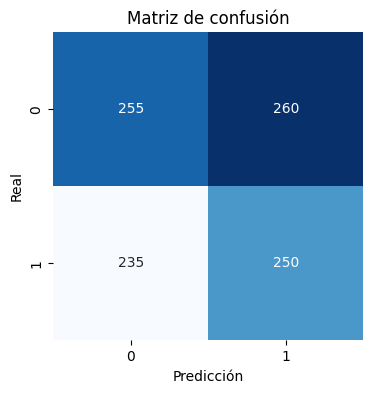

In [17]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

## 7) Umbral (threshold) y trade-off precision/recall

En clasificación binaria, `predict()` usa un umbral por defecto (típicamente 0.5):

- Si `P(y=1) >= 0.5` entonces predice 1.
- Si no, predice 0.

Cambiar el umbral cambia el equilibrio:

- Umbral **más bajo** (ej. 0.3): más positivos predichos → suele subir `recall` y bajar `precision`.

¿Explicación?
- Voy a aumentar mis positivos pero realmente pocos son buenos. … tendremos más falsos positivos y pocos verdaderos positivos. 
- Aumentan los TP, pero aumentan todavía más los FP (por eso la precisión baja).

---------
- Umbral **más alto** (ej. 0.7): menos positivos predichos → suele subir `precision` y bajar `recall`.

¿Explicación?
- Si subimos el umbral, nos volvemos más estrictos y solo marcamos como positivo a los casos con probabilidad muy alta. Eso reduce los falsos positivos (FP), así que la precision sube, pero aumenta los falsos negativos (FN) (positivos reales que ya no alcanzan el umbral), por lo que el recall baja

Esto es clave en negocio:

- Si el costo de **no dar promoción a alguien que sí la necesitaba** es alto → priorizas `recall`.
- Si el costo de **dar promoción innecesaria** es alto → priorizas `precision`.

In [18]:
from sklearn.metrics import classification_report

for thr in [0.3, 0.5, 0.7]:
    y_pred_thr = (y_pred_proba >= thr).astype(int)
    print(f"\n--- Threshold = {thr} ---")
    print(classification_report(y_test, y_pred_thr))


--- Threshold = 0.3 ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       515
           1       0.48      1.00      0.65       485

    accuracy                           0.48      1000
   macro avg       0.24      0.50      0.33      1000
weighted avg       0.24      0.48      0.32      1000


--- Threshold = 0.5 ---
              precision    recall  f1-score   support

           0       0.52      0.50      0.51       515
           1       0.49      0.52      0.50       485

    accuracy                           0.51      1000
   macro avg       0.51      0.51      0.50      1000
weighted avg       0.51      0.51      0.51      1000


--- Threshold = 0.7 ---
              precision    recall  f1-score   support

           0       0.52      1.00      0.68       515
           1       0.00      0.00      0.00       485

    accuracy                           0.52      1000
   macro avg       0.26      0.50      0.34      1000

d:\Documentos\Proyectos de Python\APRENDIZAJE AUTOMÁTICO EN LA NUBE\MLOps_UdM-main 2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Documentos\Proyectos de Python\APRENDIZAJE AUTOMÁTICO EN LA NUBE\MLOps_UdM-main 2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Documentos\Proyectos de Python\APRENDIZAJE AUTOMÁTICO EN LA NUBE\MLOps_UdM-main 2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in label

In [19]:
# Evaluate
from sklearn.metrics import classification_report, roc_auc_score

print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))
print("\nClassification Report (threshold=0.5):")
print(classification_report(y_test, y_pred))

ROC-AUC Score: 0.483050745671104

Classification Report (threshold=0.5):
              precision    recall  f1-score   support

           0       0.52      0.50      0.51       515
           1       0.49      0.52      0.50       485

    accuracy                           0.51      1000
   macro avg       0.51      0.51      0.50      1000
weighted avg       0.51      0.51      0.51      1000



## **Actividad**

Prueba:

1. Imputar los numericos con otras estrategias
2. Crea nuevas features
3. Usar BinaryEncoder para las categoricas
4. Usar MinMaxScaler para las numericas
5. Usar RandomForestClassifier para el modelo
6. Usar GridSearchCV para encontrar los mejores hiperparametros
7. Juega con el split de datos


Subir a repositorio invividual con la solución. 